# Practice 2.
##  Objectives:
1. Learn to clean data with pandas.

2. Do a simple Linear regression

## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)
1.   Cars data: http://archive.ics.uci.edu/ml/datasets/Automobile.
- Predict **price** in dollars.

2. Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)


___________________________________

## First we load the Libraries
* Pandas: For dealing with tabulated data: excel + sql
* sklearn: Machine learning framework
* os: anciliary functions for dealing with the operating system

In [1]:
import pandas as pd
import os 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

### Use the os library for generating the path to the file

In [67]:
File = "Bdcars.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\SecondPractice\Data\Bdcars.csv


### First rows of the file
**make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price**

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500

alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500

### Load the data by means of Pandas
- Note that the structure is a csv: Comma separated values
- The library recognizes the first line as the name of the columns
- Note the similarity with an *excel file*

#  See Appendix for  the meaning of the variables.

In [68]:
Data = pd.read_csv(Filename)
Data.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [32]:
print(f'Size of the database: {Data.shape} (rows X columns)')

Size of the database: (205, 24) (rows X columns)


## Next we get general information about the dataframe
## Dtype -> will allow to see which transformations should be done

In [33]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               205 non-null    str    
 1    fuel-type          205 non-null    str    
 2    aspiration         205 non-null    str    
 3    num-of-doors       205 non-null    str    
 4    body-style         205 non-null    str    
 5    drive-wheels       205 non-null    str    
 6    engine-location    205 non-null    str    
 7    wheel-base         205 non-null    float64
 8    length             205 non-null    float64
 9    width              205 non-null    float64
 10   height             205 non-null    float64
 11   curb-weight        205 non-null    int64  
 12   engine-type        205 non-null    str    
 13   num-of-cylinders   205 non-null    str    
 14   engine-size        205 non-null    int64  
 15   fuel-system        205 non-null    str    
 16   bore              

## First we clean the price feature
###  We erraise the unknowns '?'

In [69]:
Data =Data[Data[' price'] != '?']
Data[' price'] = Data[' price'].astype('float')
print('*'*30)
print('Shape of the data: ',Data.shape)
print('*'*30)
Data.info()

******************************
Shape of the data:  (201, 24)
******************************
<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               201 non-null    str    
 1    fuel-type          201 non-null    str    
 2    aspiration         201 non-null    str    
 3    num-of-doors       201 non-null    str    
 4    body-style         201 non-null    str    
 5    drive-wheels       201 non-null    str    
 6    engine-location    201 non-null    str    
 7    wheel-base         201 non-null    float64
 8    length             201 non-null    float64
 9    width              201 non-null    float64
 10   height             201 non-null    float64
 11   curb-weight        201 non-null    int64  
 12   engine-type        201 non-null    str    
 13   num-of-cylinders   201 non-null    str    
 14   engine-size        201 non-nu

## Next we deal with the categorical data.
###  Get the unique data, observe the return object is a Numpy Array of objects (strings)
###  Note: This can be done in a more straight forward way, but  the idea is to get used with the basics of pandas.

In [70]:
NamesMake = Data[' make'].unique()
print(NamesMake)

<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str


###  We create a code for each of the makes.
**NOTE**:  Categorical features, there is no order. 
**SOLUTION**: Will be given in decision trees.

### We use an implementation of 'dict comprehension' and '.map()'

In [71]:
CodeMake = list(range(len(NamesMake)))

MappingName2code = {key:float(val) for (key,val)  in zip(NamesMake,CodeMake)}
print(MappingName2code)

{'alfa-romero': 0.0, 'audi': 1.0, 'bmw': 2.0, 'chevrolet': 3.0, 'dodge': 4.0, 'honda': 5.0, 'isuzu': 6.0, 'jaguar': 7.0, 'mazda': 8.0, 'mercedes-benz': 9.0, 'mercury': 10.0, 'mitsubishi': 11.0, 'nissan': 12.0, 'peugot': 13.0, 'plymouth': 14.0, 'porsche': 15.0, 'renault': 16.0, 'saab': 17.0, 'subaru': 18.0, 'toyota': 19.0, 'volkswagen': 20.0, 'volvo': 21.0}


In [72]:
Data[' make'].map(MappingName2code)

0       0.0
1       0.0
2       0.0
3       1.0
4       1.0
       ... 
200    21.0
201    21.0
202    21.0
203    21.0
204    21.0
Name:  make, Length: 201, dtype: float64

In [73]:
Data[' make'] = Data[' make'].map(MappingName2code)
Data.T.head()

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0
fuel-type,gas,gas,gas,gas,gas,gas,gas,gas,gas,gas,...,gas,gas,gas,gas,gas,gas,gas,gas,diesel,gas
aspiration,std,std,std,std,std,std,std,std,turbo,std,...,std,std,std,turbo,turbo,std,turbo,std,turbo,turbo
num-of-doors,two,two,two,four,four,two,four,four,four,two,...,four,four,four,four,four,four,four,four,four,four
body-style,convertible,convertible,hatchback,sedan,sedan,sedan,sedan,wagon,sedan,sedan,...,wagon,sedan,wagon,sedan,wagon,sedan,sedan,sedan,sedan,sedan


 ### Excercise: <font color='red'>Correct all the categorical fields </font>
 Note: In case there is an order, such as **num-of-doors** make a coding that follows the order.

<span style="color:green">First we will erase the numerical fields</span>

In [74]:
columns_correct = [" bore", " stroke", " peak-rpm", " horsepower"]
mask = (Data[columns_correct] != '?').all(axis=1)
Data = Data[mask]
Data[columns_correct] = Data[columns_correct].astype('float')
print('Shape of the data: ',Data.shape)
Data.info()

Shape of the data:  (195, 24)
<class 'pandas.DataFrame'>
Index: 195 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               195 non-null    float64
 1    fuel-type          195 non-null    str    
 2    aspiration         195 non-null    str    
 3    num-of-doors       195 non-null    str    
 4    body-style         195 non-null    str    
 5    drive-wheels       195 non-null    str    
 6    engine-location    195 non-null    str    
 7    wheel-base         195 non-null    float64
 8    length             195 non-null    float64
 9    width              195 non-null    float64
 10   height             195 non-null    float64
 11   curb-weight        195 non-null    int64  
 12   engine-type        195 non-null    str    
 13   num-of-cylinders   195 non-null    str    
 14   engine-size        195 non-null    int64  
 15   fuel-system        195 non-null    str    

<span style="color:green">Second we are going to correct the categorical fields with a order</span>

In [75]:
columns_correct = [" num-of-doors", " num-of-cylinders"]
mask = (Data[columns_correct] != '?').all(axis=1)
Data = Data[mask]
Data[" num-of-doors"] = Data[" num-of-doors"].map({
    "two": 2,
    "four": 4
}).astype(float)
Data[" num-of-cylinders"] = Data[" num-of-cylinders"].map({
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}).astype(float)
print('Shape of the data: ',Data.shape)
Data.info()

Shape of the data:  (193, 24)
<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    str    
 2    aspiration         193 non-null    str    
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    str    
 5    drive-wheels       193 non-null    str    
 6    engine-location    193 non-null    str    
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    str    
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    str    

<span style="color:green">Third we are going to correct the categorical fields with no order as before</span>

In [76]:
columns_correct = [" fuel-type", " aspiration", " body-style", " drive-wheels", " engine-location", " engine-type", " fuel-system"]
for col in columns_correct:
    unique_values = Data[col].unique()
    print(f"Unique values in {col}: {unique_values}")
    CodeMake = list(range(len(unique_values)))
    mapping = {key:float(val) for (key,val)  in zip(unique_values,CodeMake)}
    print(mapping)
    Data[col] = Data[col].map(mapping)

Unique values in  fuel-type: <StringArray>
['gas', 'diesel']
Length: 2, dtype: str
{'gas': 0.0, 'diesel': 1.0}
Unique values in  aspiration: <StringArray>
['std', 'turbo']
Length: 2, dtype: str
{'std': 0.0, 'turbo': 1.0}
Unique values in  body-style: <StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str
{'convertible': 0.0, 'hatchback': 1.0, 'sedan': 2.0, 'wagon': 3.0, 'hardtop': 4.0}
Unique values in  drive-wheels: <StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str
{'rwd': 0.0, 'fwd': 1.0, '4wd': 2.0}
Unique values in  engine-location: <StringArray>
['front', 'rear']
Length: 2, dtype: str
{'front': 0.0, 'rear': 1.0}
Unique values in  engine-type: <StringArray>
['dohc', 'ohcv', 'ohc', 'l', 'ohcf']
Length: 5, dtype: str
{'dohc': 0.0, 'ohcv': 1.0, 'ohc': 2.0, 'l': 3.0, 'ohcf': 4.0}
Unique values in  fuel-system: <StringArray>
['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', 'idi', 'spdi']
Length: 7, dtype: str
{'mpfi': 0.0, '2bbl': 1.0, 'mfi': 2.0, '

In [77]:
# Data[columns_correct].T.head()
Data.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    float64
 2    aspiration         193 non-null    float64
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    float64
 5    drive-wheels       193 non-null    float64
 6    engine-location    193 non-null    float64
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    float64
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    float64
 16   bore               193 

 ### Next we will eraise the columns that have not been corrected.
 ### Also will correct the integers to floats.

In [78]:
Data.columns

Index([' make', ' fuel-type', ' aspiration', ' num-of-doors', ' body-style',
       ' drive-wheels', ' engine-location', ' wheel-base', ' length', ' width',
       ' height', ' curb-weight', ' engine-type', ' num-of-cylinders',
       ' engine-size', ' fuel-system', ' bore', ' stroke',
       ' compression-ratio', ' horsepower', ' peak-rpm', ' city-mpg',
       ' highway-mpg', ' price'],
      dtype='str')

In [79]:
TypeOfColumn = Data.dtypes
print(TypeOfColumn)

make                 float64
fuel-type            float64
aspiration           float64
num-of-doors         float64
body-style           float64
drive-wheels         float64
engine-location      float64
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type          float64
num-of-cylinders     float64
engine-size            int64
fuel-system          float64
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [80]:
cols2drop = list()
for col,dtype in zip(Data.columns,TypeOfColumn):
    print(f' Name of columns:{col}   \t||| Type of column: {dtype}')
    if dtype == 'object':
        cols2drop.append(col)

 Name of columns: make   	||| Type of column: float64
 Name of columns: fuel-type   	||| Type of column: float64
 Name of columns: aspiration   	||| Type of column: float64
 Name of columns: num-of-doors   	||| Type of column: float64
 Name of columns: body-style   	||| Type of column: float64
 Name of columns: drive-wheels   	||| Type of column: float64
 Name of columns: engine-location   	||| Type of column: float64
 Name of columns: wheel-base   	||| Type of column: float64
 Name of columns: length   	||| Type of column: float64
 Name of columns: width   	||| Type of column: float64
 Name of columns: height   	||| Type of column: float64
 Name of columns: curb-weight   	||| Type of column: int64
 Name of columns: engine-type   	||| Type of column: float64
 Name of columns: num-of-cylinders   	||| Type of column: float64
 Name of columns: engine-size   	||| Type of column: int64
 Name of columns: fuel-system   	||| Type of column: float64
 Name of columns: bore   	||| Type of column:

In [81]:
print(cols2drop)

[]


In [82]:
Data.drop(cols2drop,axis = 1).T

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,2.0,...,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
fuel-type,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
aspiration,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.0,...,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
num-of-doors,2.00,2.00,2.00,4.00,4.00,2.00,4.00,4.00,4.00,2.0,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
body-style,0.00,0.00,1.00,2.00,2.00,2.00,2.00,3.00,2.00,2.0,...,3.00,2.00,3.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00
drive-wheels,0.00,0.00,0.00,1.00,2.00,1.00,1.00,1.00,1.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
engine-location,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
wheel-base,88.60,88.60,94.50,99.80,99.40,99.80,105.80,105.80,105.80,101.2,...,104.30,104.30,104.30,104.30,104.30,109.10,109.10,109.10,109.10,109.10
length,168.80,168.80,171.20,176.60,176.60,177.30,192.70,192.70,192.70,176.8,...,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80
width,64.10,64.10,65.50,66.20,66.40,66.30,71.40,71.40,71.40,64.8,...,67.20,67.20,67.20,67.20,67.20,68.90,68.80,68.90,68.90,68.90


In [ ]:
Data = Data.drop(cols2drop,axis = 1)

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    float64
 2    aspiration         193 non-null    float64
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    float64
 5    drive-wheels       193 non-null    float64
 6    engine-location    193 non-null    float64
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    float64
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    float64
 16   bore               193 

## Before doing the linear regression analize the scatter plots


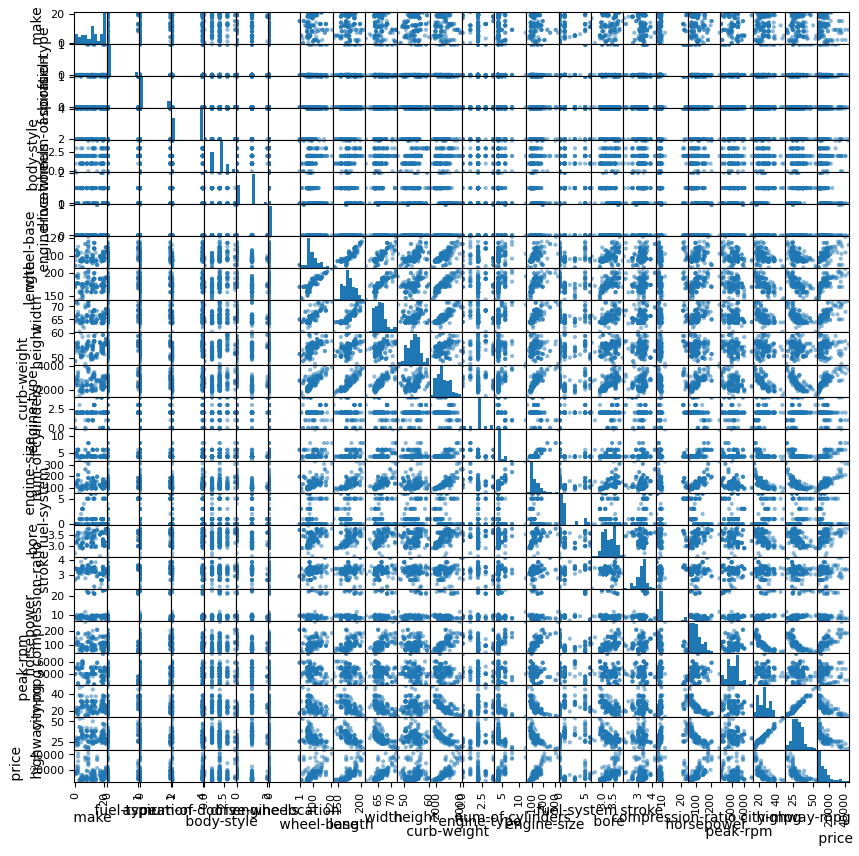

In [55]:
ax = pd.plotting.scatter_matrix(Data,figsize = (10,10))

### Excercise 
1. <font color='red'> Relate price (target) to a subset of features </font>
2. <font color='red'> Relate  subset of features ' city-mpg',' length',' engine-size' between themselves </font>

* In theory we will explain why it is usefull, but first try to understand

In [63]:
print(Data.columns.values)

[' make' ' wheel-base' ' length' ' width' ' height' ' curb-weight'
 ' engine-size' ' compression-ratio' ' city-mpg' ' highway-mpg' ' price']


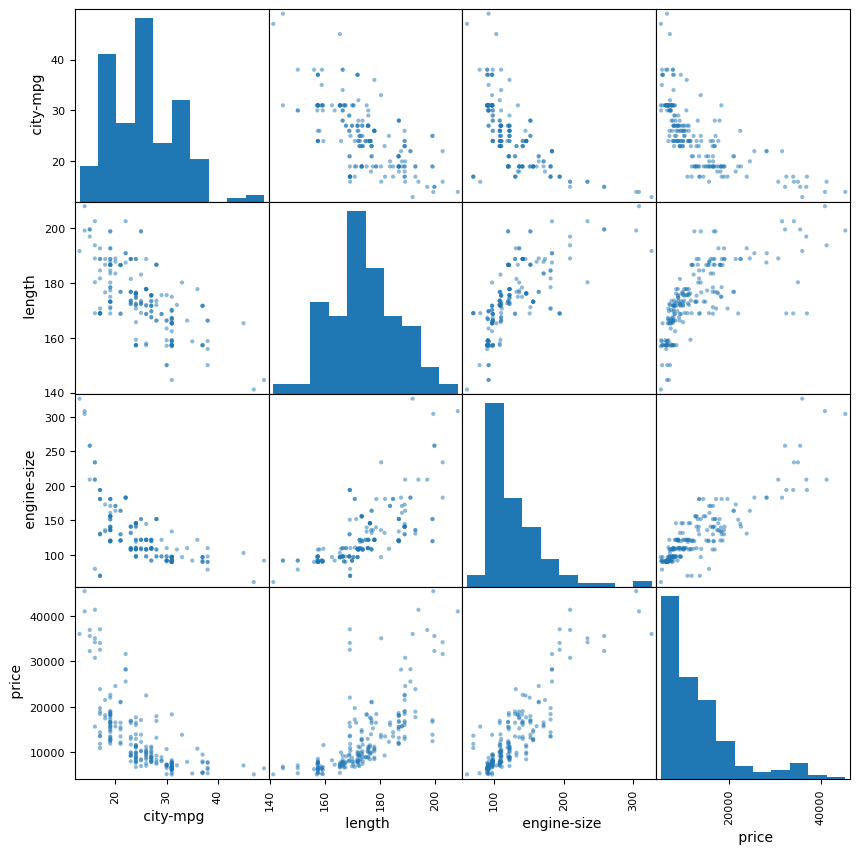

In [64]:
ax = pd.plotting.scatter_matrix(Data[[' city-mpg',' length',' engine-size',' price']],figsize = (10,10))

### Excercise 
1. <font color='red'> Explain in words, why correlation between input variables is bad, but with the output is good. </font>


 ## Now we will make a model that predicts the price given the features
 ###  Note that it will be a linear model. 
 
 * The scatter plot indicates that possibly we could use second order polynomials for fitting, but we have freedom for deciding the model.
 * There are other considerations for prefering a **linear model**.
 ###  First we create the database.

In [65]:
Input = Data[[' make', ' wheel-base' ,' length', ' width' ,' height', ' curb-weight',
 ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg']]
Price = Data[[' price']]

### Next we estimate the parameters by **min squares**

In [66]:
from sklearn import linear_model
CarPrice = linear_model.LinearRegression()
CarPrice.fit (Input, Price)

print(CarPrice.coef_)
print(CarPrice.intercept_)

[[-148.82889015  -70.31708587  -73.82912216  660.09875577  266.01525777
     2.19936224  111.51765344  209.52567962 -488.05504384  216.46274134]]
[-39203.40473429]


In [67]:
print(Input.columns)

Index([' make', ' wheel-base', ' length', ' width', ' height', ' curb-weight',
       ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg'],
      dtype='object')


In [68]:
df_car_coef = pd.DataFrame(CarPrice.coef_,columns = Input.columns)
df_car_coef

,make,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
0,-148.82889,-70.317086,-73.829122,660.098756,266.015258,2.199362,111.517653,209.52568,-488.055044,216.462741


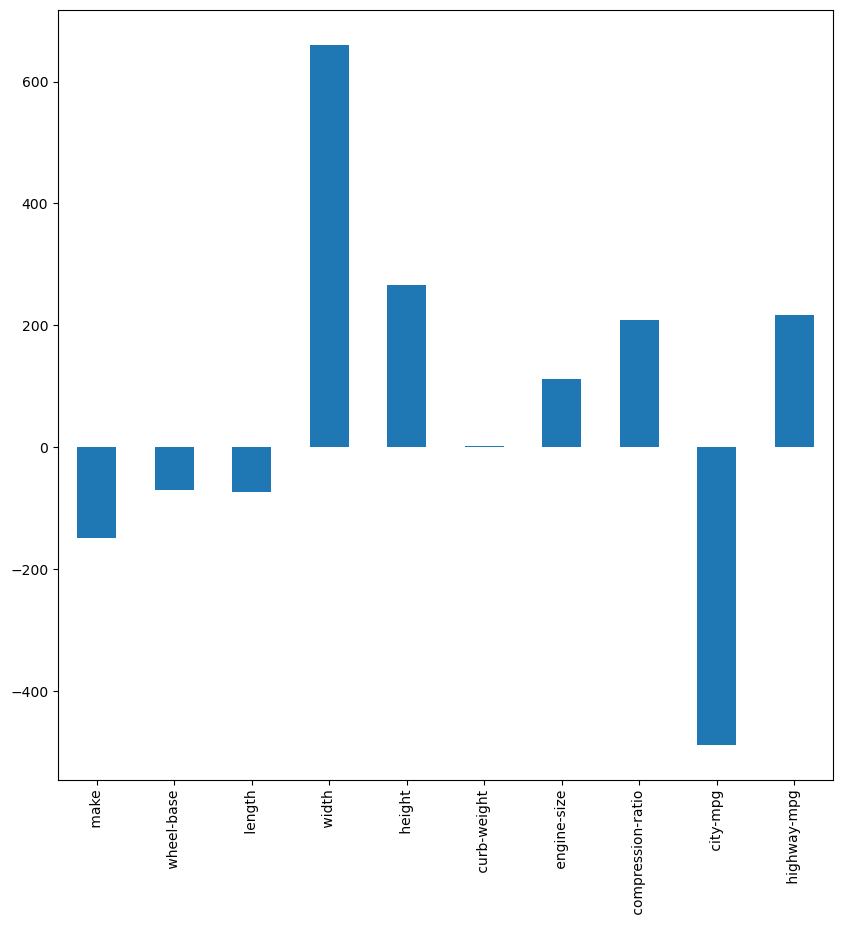

In [69]:
_ = df_car_coef.T.plot(kind = 'bar',figsize = (10,10),legend = False)


### Excercise 
1. <font color='red'> Explain in words, the meaning of each of the values of the weights. What sense do they have? </font>

2. <font color='red'> If collecting a database is expensive, what recommendation would you give? </font>


## We will see how it works over the training database.
### Note that the correct way is to use a validation database, which we will see below

In [70]:
PredictedPrice  = CarPrice.predict(Input)

### Scatter plot. 
* Ideal relationship should be linear

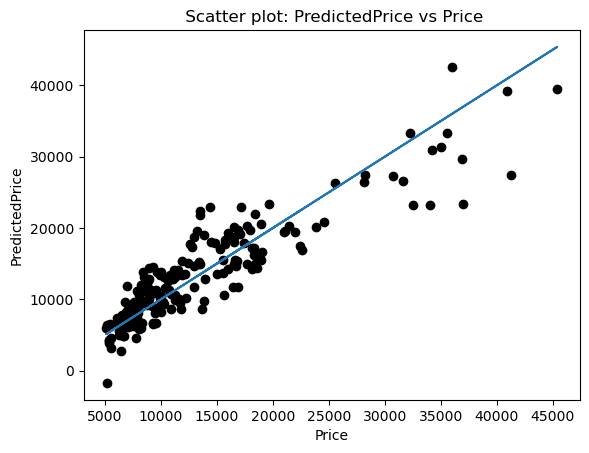

In [71]:
plt.scatter(Price, PredictedPrice,   color='black')
plt.title(' Scatter plot: PredictedPrice vs Price')
plt.plot(Price,Price)
plt.xlabel('Price')
plt.ylabel('PredictedPrice')
plt.show()

## Performance of the model on the training database

* Mean squared error:   
 $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$
* Explained variance ($R^2$):   
$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

In [72]:
from sklearn.metrics import mean_squared_error
print (f'MSE = {mean_squared_error(Price, PredictedPrice):2.2f} ')
print (f'Root MSE = {np.sqrt(mean_squared_error(Price, PredictedPrice)):2.2f} ')

MSE = 10901622.45 
Root MSE = 3301.76 


In [73]:
from sklearn.metrics import r2_score
print (f'Explained Variance: $r^2$ = {r2_score(Price, PredictedPrice)*100.:2.2f} %')

Explained Variance: $r^2$ = 82.65 %


### Excercise 
1. <font color='red'> Explain in words, why r^2 is more usefull than MSE. </font>




##  Need for Cross-validation

###  Definition
Cross-validation is a statistical technique used in machine learning to evaluate how well a model generalizes to independent datasets.

1. It consists of dividing the training dataset into several parts, or folds, typically between 5 and 10 (See figure below).
<img src="EsquemaValidacioCreuada.png" width="60%">

2. One of the folds is reserved as a test set, while the rest are used to train the model. This process is repeated as many times as there are folds, so that each part of the dataset acts as a test set once.

3. Utility of validation:
   1. Detects overfitting, i.e., when a model adapts too much to the specific details of the training data and does not perform well with new examples.
   2. Through cross-validation, one can **better adjust the model parameters** to achieve a balance between fitting the training data and the ability to generalize.
   3. Allows creating more robust and reliable models, increasing confidence in the predictions made by these models in real-world situations.

In [74]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Set up 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute MSE using cross-validation (negative because sklearn uses negative MSE)
mse_scores = -cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# Compute R^2 using cross-validation
r2_scores = cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='r2')

# Display results
print("Cross-Validation Results (5-Fold):")
print(f"MSE scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.2f} (+/- {mse_scores.std():.2f})")
print(f"\nRMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
print(f"\nR^2 scores: {r2_scores}")
print(f"Mean R^2: {r2_scores.mean()*100:.2f}% (+/- {r2_scores.std()*100:.2f}%)")

Cross-Validation Results (5-Fold):
MSE scores: [28732038.13689413 11169676.30121719 12261646.12454769  7459242.78070394
 10462115.37435085]
Mean MSE: 14016943.74 (+/- 7528110.67)

RMSE scores: [5360.22743332 3342.10656641 3501.66333684 2731.16143439 3234.51934209]
Mean RMSE: 3633.94 (+/- 900.81)

R^2 scores: [0.765159   0.50454074 0.82457363 0.71929577 0.81351366]
Mean R^2: 72.54% (+/- 11.66%)


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
1. Explain in words, why the cross validation provides a more accurate estimate of what happens with unseen data.
2. Explain in words, the usefulness of having a confidence margin.

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


### Excercise: <font color='red'> Repeat the practice with the database **Wine Quality** target (**quality**) </font>

In [75]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\Users\enric\Desktop\Mlearn2026\PracticesML\SecondPractice\SecondPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


## Appendix:
### Description of the variables
 1. make: The name of the produces of the car (a factor).
 - alfa-romero, audi, bmw, chevrolet, dodge, honda,  isuzu, jaguar, mazda, mercedes-benz, mercury,mitsubishi, nissan, peugot, plymouth, porsche,renault, saab, subaru, toyota, volkswagen, volvo
 
2. fuel-type: The type of fuel used by the car, either diesel or gas (a factor).
 - diesel, gas.
3. aspiration:	Type of aspiration of fuel in the motor
- std, turbo.
4. num-of-doors: The number of passenger doors, either two or four (a factor).
 - four, two.
5. body-styleThe type of the car (a factor).
- hardtop, wagon, sedan, hatchback, convertible.
6. drive-wheels: The wheels powered by the engine (a factor).
- 4wd, fwd, rwd.
7. engine-location: The location in the car of the engine (a factor).
- front, rear.
8. wheel-base: The distance between the centers of the front and rear wheels in inches (numeric).	
- continuous from 86.6 120.9.
9. length: The length of the body of the car in inches (numeric).
- continuous from 141.1 to 208.1.
10. width: The width of the body of the car in inches (numeric).
- continuous from 60.3 to 72.3.
11. height: The height of the car in inches (numeric).
- continuous from 47.8 to 59.8.
12. curb-weight: The total weight in pounds of a vehicle with standard equipment and a full tank of fuel, but with no passengers or cargo (numeric).	 
- continuous from 1488 to 4066.
13. engine-type: Mechanical Feature  (numeric).	 
- dohc, dohcv, l, ohc, ohcf, ohcv, rotor.
14. num-of-cylinders:: Mechanical Feature  (a factor).
- eight, five, four, six, three, twelve, two.
15. engine-size: The volume swept by all the pistons inside the cylinders in cubic inches (numeric).
 - continuous from 61 to 326.
16. fuel-system: Mechanical Feature  (a factor).
- 1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.
17. bore: Mechanical Feature  (numeric).	
- continuous from 2.54 to 3.94.
18. stroke: Mechanical Feature  (numeric).	 
- continuous from 2.07 to 4.17.
19. compression-ratio: Mechanical Feature  (numeric).	  
- continuous from 7 to 23.
20. horsepower: The power of the engine in horsepowers (numeric).	
- continuous from 48 to 288.
21. peak-rpm: The top speed of the engine in rounds-per-minute (numeric).
- continuous from 4150 to 6600.
22. city-mpg: The fuel consumption of the car in city driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 13 to 49.
23. highway-mpg: The fuel consumption of the car in highway driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 16 to 54.
24. price: The retail price of the car in US Dollars (numeric).	
- continuous from 5118 to 45400.

    

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
